P.K.M.P. KUMARA
230353N 

1. Implement the intensity transformation

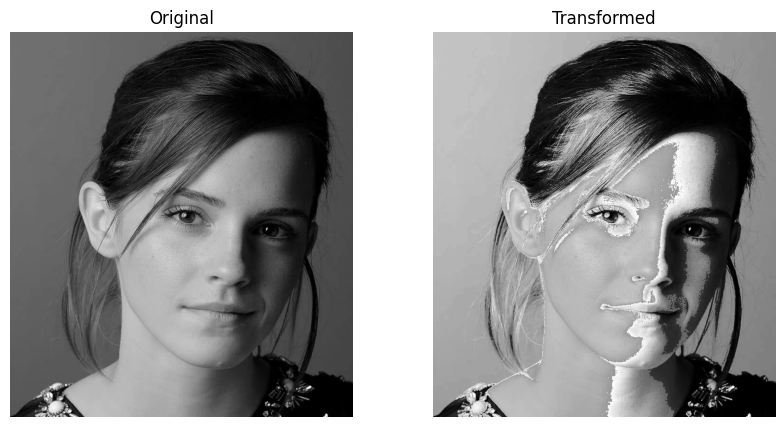

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def intensity_transform(im, breakpoints):   #Define Intensity Transform Func.
    im = np.asarray(im, dtype=np.float64)
    output = np.zeros_like(im)
    filled = np.zeros_like(im, dtype=bool)

    for i in range(len(breakpoints) - 1):
        x0, y0 = breakpoints[i]
        x1, y1 = breakpoints[i + 1]

        if x1 == x0:
            continue  # vertical jump, skip

        mask = (im >= x0) & (im <= x1) & (~filled)
        output[mask] = y0 + (y1 - y0) * (im[mask] - x0) / (x1 - x0)
        filled |= mask

    return np.clip(output, 0, 255).astype(np.uint8)

img = Image.open('emma_01.jpg').convert('L')  #image in grayscale
img_arr = np.array(img)

breakpoints = [                    #Breakpoints
    [0,   0],
    [50,  50],
    [50,  100],
    [150, 255],
    [150, 150],
    [255, 255],
]

transformed = intensity_transform(img_arr, breakpoints) # Apply transform
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  #show original and transformed pics
axes[0].imshow(img_arr, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(transformed, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Transformed')
axes[1].axis('off')
plt.show()

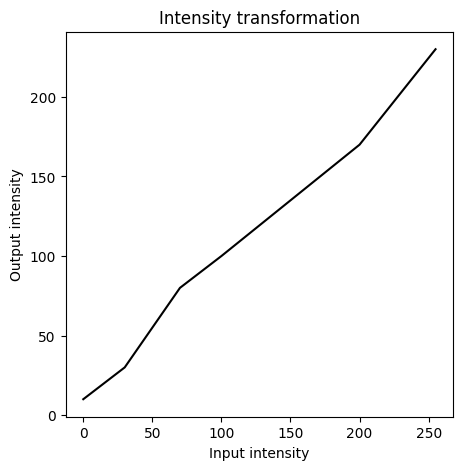

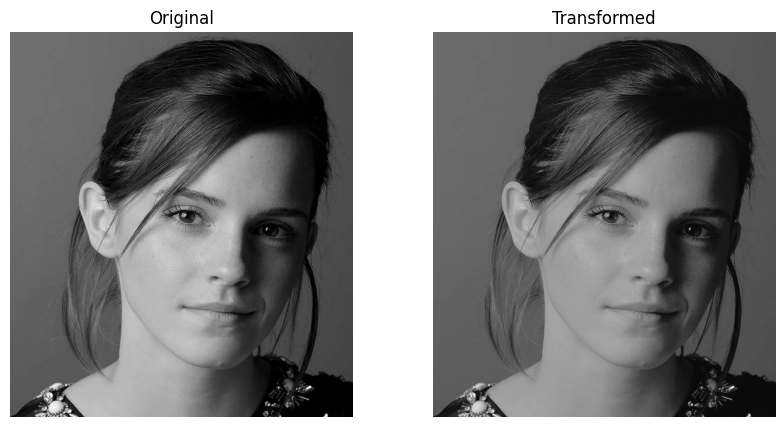

In [4]:
breakpoints = [      #my break points
    [0,   10],
    [30, 30],            #keep hair looking pleasant black
    [70, 80],
    [100, 100],
    [200, 170],          #left side of the face more bright. I reduced it.
    [255, 230],
]

transformed = intensity_transform(img_arr, breakpoints)

bp = np.array(breakpoints)         #plot transformation graph
plt.figure(figsize=(5, 5))
plt.plot(bp[:, 0], bp[:, 1], color='black')
plt.xlabel('Input intensity')
plt.ylabel('Output intensity')
plt.title('Intensity transformation')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_arr, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(transformed, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Transformed')
axes[1].axis('off')
plt.show()

2. White matter , Gray matter of the brain

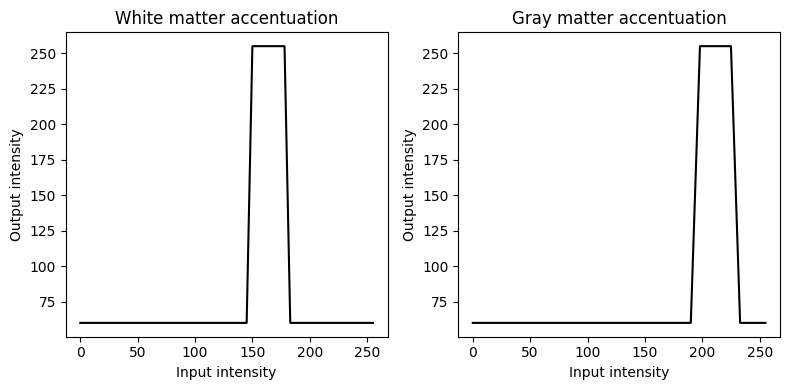

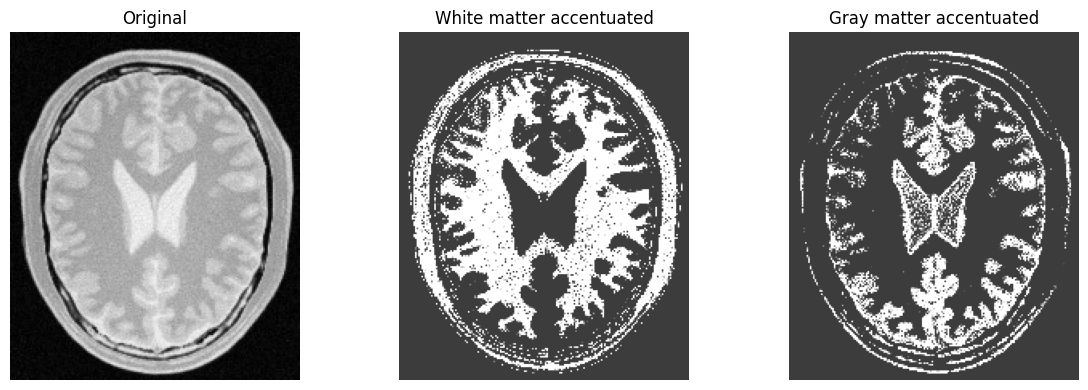

In [7]:
wm_breakpoints = [
    [0,   60],
    [145, 60],
    [150, 255],
    [178, 255],
    [183, 60],
    [255, 60],
]

gm_breakpoints = [
    [0,   60],
    [190, 60],
    [198, 255],
    [225, 255],
    [233, 60],
    [255, 60],
]

wm_img = intensity_transform(arr, wm_breakpoints)
gm_img = intensity_transform(arr, gm_breakpoints)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for ax, (bp, name) in zip(axes, [(wm_breakpoints, 'White matter'), (gm_breakpoints, 'Gray matter')]):
    bp_arr = np.array(bp)
    ax.plot(bp_arr[:, 0], bp_arr[:, 1], color='black')
    ax.set_xlabel('Input intensity')
    ax.set_ylabel('Output intensity')
    ax.set_title(f'{name} accentuation')
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(arr, cmap='gray', vmin=0, vmax=255); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(wm_img, cmap='gray', vmin=0, vmax=255); axes[1].set_title('White matter accentuated'); axes[1].axis('off')
axes[2].imshow(gm_img, cmap='gray', vmin=0, vmax=255); axes[2].set_title('Gray matter accentuated'); axes[2].axis('off')
plt.tight_layout()
plt.show()

3. Gamma correction and histogram

Hello
Hello
